In [1]:
from functions.clustering_functions import clustering_2_communities, ARI_fscore
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])
from functions.plots import plot_ARI_f1
from functions.main_functions import load_presaved_data, normal_run, run_squic_fit, run_squic, ask_yes_no, ask_input
from functions.cosmograph_functions import visualize_graph_internal

In [2]:
user_input = ask_yes_no("\nDo you want to load data?")

name = 'PAYSIM'
if user_input == 'Y':
    Y_norm, knn_matrix, account_prop, dimension = load_presaved_data(name)
    
else: # Normal run
    Y_norm, knn_matrix, account_prop, dimension = normal_run(name)
    
results_squic = {}
# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':
    results_squic, squic_method, save = run_squic_fit(Y_norm, knn_matrix, results_squic, name, dimension)
    
else:
    results_squic, squic_method, save = run_squic(Y_norm, results_squic, name, dimension)

Head of Y_norm df:
          0         1         2         3         4         5         6  \
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1  0.021057  0.054107  0.054107  0.054107  0.054107  0.054107  0.054107   
2  0.145583  0.217017  0.217017  0.217017  0.217017  0.217017  0.217017   
3  0.000063  0.000063  0.000063  0.000063  0.000063  0.000063  0.000063   
4  0.000060  0.000060  0.000060  0.000060  0.000060  0.000060  0.000060   

          7         8         9  ...       355       356       357       358  \
0  0.000000  0.000000  0.000000  ...  2.928368  2.934959  2.952739  2.952739   
1  0.054107  0.054107  0.237593  ...  2.319709  2.319709  2.319697  2.178234   
2  0.217017  0.498930  0.736953  ...  2.744306  2.842049  2.841268  2.927821   
3  0.000063  0.215060  0.282816  ...  4.081573  4.081573  4.032990  4.032990   
4  0.000060  0.856894  1.758480  ...  4.367516  4.563064  4.346059  4.908558   

        359       360       361       362       3


for rho 0.6 graph is connected: False
Computing spectral clustering for rho 0.6...
For rho 0.6 takes 0.04 seconds

for rho 0.5 graph is connected: False
Computing spectral clustering for rho 0.5...
For rho 0.5 takes 0.0 seconds

for rho 0.4 graph is connected: False
Computing spectral clustering for rho 0.4...
For rho 0.4 takes 0.0 seconds

for rho 0.3 graph is connected: False
Computing spectral clustering for rho 0.3...
For rho 0.3 takes 0.0 seconds

for rho 0.2 graph is connected: True
Computing spectral clustering for rho 0.2...
For rho 0.2 takes 0.0 seconds

for rho 0.1 graph is connected: True
Computing spectral clustering for rho 0.1...
For rho 0.1 takes 0.0 seconds
for rho = 0.6 : {'spectral': {'nCluster': 2, 'ARI': -0.03, 'f1': 0.58}}
for rho = 0.5 : {'spectral': {'nCluster': 2, 'ARI': 1.0, 'f1': 1.0}}
for rho = 0.4 : {'spectral': {'nCluster': 2, 'ARI': 1.0, 'f1': 1.0}}
for rho = 0.3 : {'spectral': {'nCluster': 2, 'ARI': 0.93, 'f1': 0.99}}
for rho = 0.2 : {'spectral': {'nClus

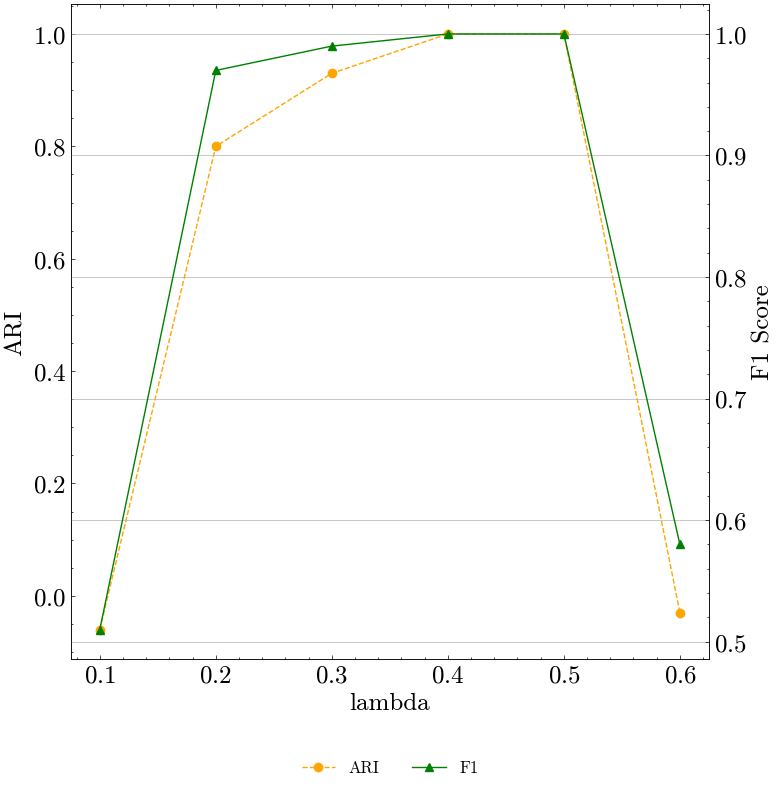

In [3]:
# Results
dict_cluster = clustering_2_communities(results_squic, squic_method)

metrics = ARI_fscore(dict_cluster, results_squic, account_prop)

for _, data in metrics.items():
    for rho, results in data.items():
        print(f"for rho = {rho} : {results}")

plot_ARI_f1(metrics, squic_method, dimension, save)

In [4]:
graph = visualize_graph_internal(results_squic, squic_method, dict_cluster, account_prop, name)

In [5]:
lambda_graph = {
    '100': 0.5,
    '1K': 0.8,
    '10K': 0.997,
    '100K': 0.99992
}

In [6]:
graph.get(lambda_graph.get(dimension))

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…